### Data Selection for Finetuning Ag slab w/ [C, H, O] adsorbates

Download OUTCAR for each pre-screened folder listed in cache/selected_foldernames.txt

In [ ]:
import os
import time
from dotenv import load_dotenv
import dropbox
from dropbox.files import SharedLink
from pymatgen.io.vasp.inputs import Incar

load_dotenv(override=True)
TOKEN = os.getenv("DROPBOX_TOKEN")

In [9]:
# read in raw folder names list from cache
with open("cache/selected_foldernames.txt", "r", encoding="utf-8") as f:
    foldernames = [line.strip() for line in f]

print(f"Total items: {len(foldernames)}")

Total items: 143


In [13]:
dbx = dropbox.Dropbox( TOKEN)

ROOT_PATH = SharedLink(url="https://www.dropbox.com/scl/fo/qpg1zuo3g7vb3il1wmqy3/AA4wERzz28lJhYTCAcSEvqk?dl=0")

In [ ]:
# download OUTCAR in every selected folder

no_outcar = []
failed_folders = {}
for folder in foldernames:
    folder_path = f"/{folder}"
    try:
        res = dbx.files_list_folder(path=folder_path, shared_link=ROOT_PATH)
        names = {e.name for e in res.entries}
    except dropbox.exceptions.ApiError as e:
        failed_folders[folder] = str(e)
        print(f"WARNING: list failed -> {folder}: {e}")
        continue
    if "OUTCAR" not in names:
        no_outcar.append(folder)
        print(f"WARNING: no OUTCAR -> {folder}")
        continue
    try:
        _, dres = dbx.sharing_get_shared_link_file(url=ROOT_PATH.url, path=f"{folder_path}/OUTCAR")
        with open(f"outcars/{folder}_OUTCAR", "wb") as f:
            f.write(dres.content)
    except dropbox.exceptions.ApiError as e:
        failed_folders[folder] = str(e)
        print(f"WARNING: download failed -> {folder}: {e}")
    time.sleep(0.2)

In [ ]:
# if folder contains >1 OUTCARs, download the greatest-enumerated one (to get the last frame)

def get_max_outcar_suffix(folder):
    """Return highest OUTCAR-N suffix number, or None if only base OUTCAR exists."""
    folder_path = f"/{folder}"
    res = dbx.files_list_folder(path=folder_path, shared_link=ROOT_PATH)
    names = {e.name for e in res.entries}

    max_n = None
    for name in names:
        m = re.fullmatch(r"OUTCAR-(\d+)", name)
        if m:
            n = int(m.group(1))
            if max_n is None or n > max_n:
                max_n = n
    return max_n

outcar_suffix_map = {}
failed_folders = {}

for folder in foldernames:
    try:
        max_n = get_max_outcar_suffix(folder)
        outcar_suffix_map[folder] = max_n  # None means just base OUTCAR
    except dropbox.exceptions.ApiError as e:
        failed_folders[folder] = str(e)
        print(f"WARNING: failed -> {folder}: {e}")
    time.sleep(0.2)

Check energy trajectory of folders that are potentially not relaxations.

In [1]:
import matplotlib.pyplot as plt

In [9]:
import re
import math
import matplotlib.pyplot as plt

def get_energies(outcar_path):
    energies = []
    with open(outcar_path, "r", errors="ignore") as f:
        for line in f:
            if "free  energy   TOTEN" in line:
                energies.append(float(line.split()[-2]))
    return energies

def downsample(vals, max_points=30):
    if len(vals) <= max_points:
        return list(range(1, len(vals)+1)), vals
    idx = [round(i * (len(vals)-1) / (max_points-1)) for i in range(max_points)]
    idx = sorted(set(idx))
    return [i+1 for i in idx], [vals[i] for i in idx]

def plot_energy_trajectories(folders, outcar_dir="outcars"):
    n = len(folders)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3.5 * nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, folder in zip(axes, folders):
        path = f"{outcar_dir}/{folder}_OUTCAR"
        try:
            energies = get_energies(path)
            steps, e = downsample(energies)
            ax.plot(steps, e, marker="o", markersize=3)
            ax.text(0.98, 0.95, f"n={len(energies)}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=8)
        except Exception as ex:
            ax.text(0.5, 0.5, f"failed: {ex}", ha="center", va="center")
        ax.set_title(folder, fontsize=9)
        ax.set_xlabel("step")
        ax.set_ylabel("E (eV)")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

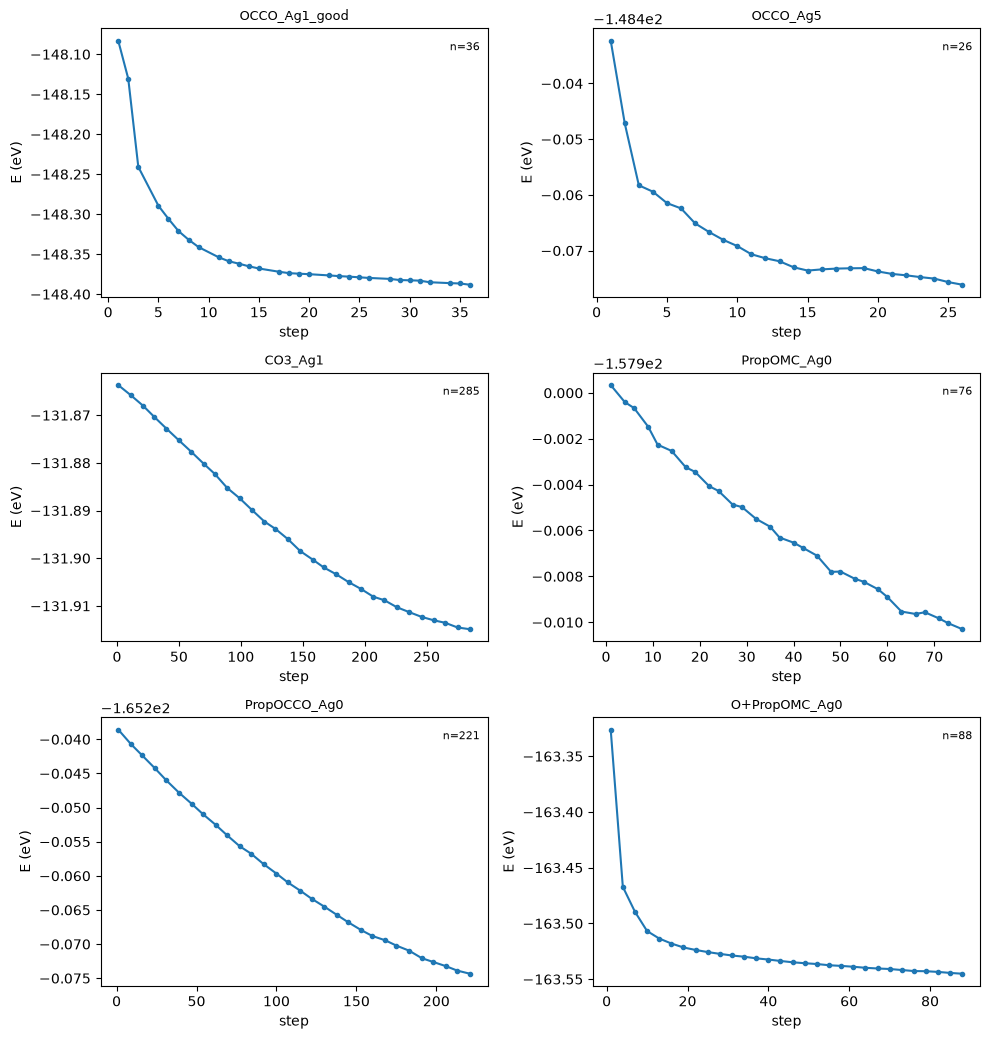

In [16]:
plot_energy_trajectories(["OCCO_Ag1_good", "OCCO_Ag5", "CO3_Ag1", "PropOMC_Ag0", "PropOCCO_Ag0", "O+PropOMC_Ag0"])

Based on visual inspection of ionic step vs. energy (ev) plots, these don't look like nicely-converged relaxations (and have been removed):
* 1Oalt_OsubAg_2x2
* O2Above_OonAg
* 2OAg (too few frames, n=6)
* OCCO_Ag0 (linear, doesn't look properly converged)
* O+OMC_HToO_Ag1, 2, 5 (those don't look like converged relaxations to me...)
* 

Get "first" and last frame of each OUTCAR